In [1]:
# ── IMPORTS & DATABASE CONNECTION ──────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
from dotenv import load_dotenv
import os

load_dotenv()

connection_url = URL.create(
    drivername="postgresql+psycopg2",
    username=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    host=os.getenv("DB_HOST"),
    port=int(os.getenv("DB_PORT")),
    database=os.getenv("DB_NAME")
)

engine = create_engine(connection_url)

with engine.connect() as conn:
    print("✅ Connected to loan_portfolio database successfully!")

✅ Connected to loan_portfolio database successfully!


In [5]:
# ── SECTION 1: PORTFOLIO SUMMARY ───────────────────────
portfolio_summary = pd.read_sql("""
    SELECT 
        loan_status,
        COUNT(*) AS number_of_loans,
        SUM(loan_amount) AS total_loan_amount,
        ROUND(AVG(loan_amount), 2) AS average_loan_amount,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS portfolio_percentage
    FROM loans
    GROUP BY loan_status
    ORDER BY total_loan_amount DESC
""", engine)

print("=" * 55)
print("        PORTFOLIO SUMMARY BY LOAN STATUS")
print("=" * 55)
print(portfolio_summary.to_string(index=False))
print("=" * 55)
print(f"TOTAL LOANS: {portfolio_summary['number_of_loans'].sum()}")
print(f"TOTAL PORTFOLIO VALUE: NGN {portfolio_summary['total_loan_amount'].sum():,.2f}")

        PORTFOLIO SUMMARY BY LOAN STATUS
loan_status  number_of_loans  total_loan_amount  average_loan_amount  portfolio_percentage
     Active               95       238424496.79           2509731.55                  47.5
 Fully Paid               50       140484792.83           2809695.86                  25.0
 Delinquent               46       122976071.41           2673392.86                  23.0
Written Off                9        22249324.22           2472147.14                   4.5
TOTAL LOANS: 200
TOTAL PORTFOLIO VALUE: NGN 524,134,685.25


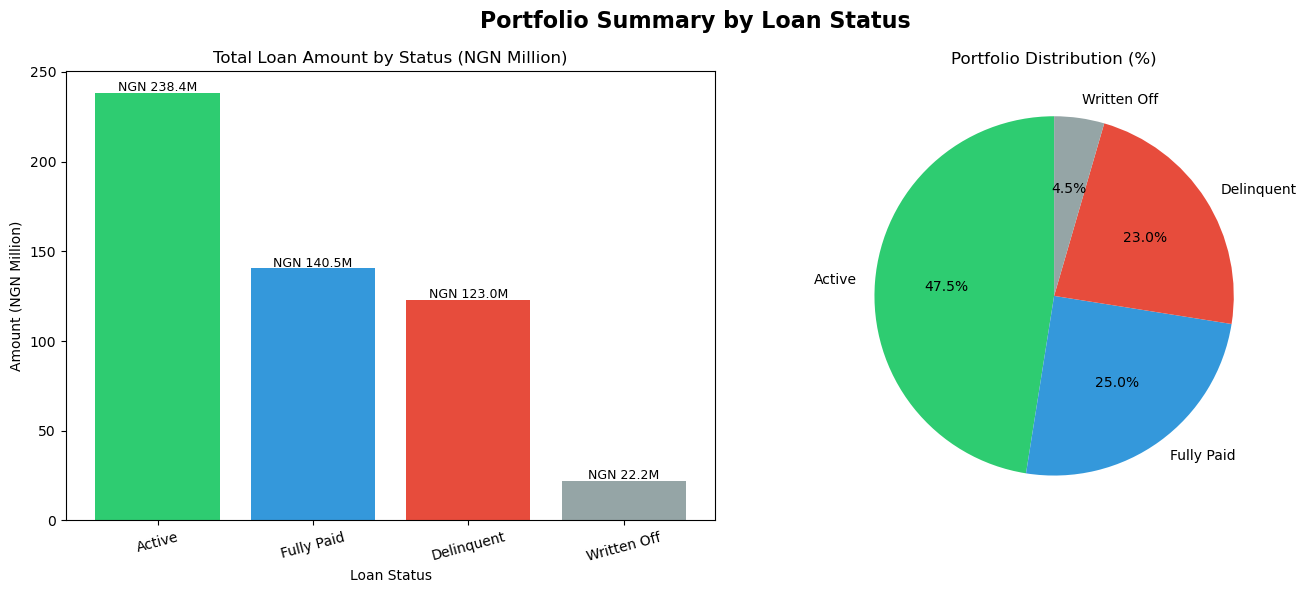

✅ Chart saved to dashboard folder


In [7]:
# ── SECTION 1: VISUALISATION ───────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Portfolio Summary by Loan Status', fontsize=16, fontweight='bold')

colors = ['#2ecc71', '#3498db', '#e74c3c', '#95a5a6']

# Bar chart — total loan amount by status
ax1.bar(portfolio_summary['loan_status'], 
        portfolio_summary['total_loan_amount'] / 1_000_000,
        color=colors)
ax1.set_title('Total Loan Amount by Status (NGN Million)')
ax1.set_xlabel('Loan Status')
ax1.set_ylabel('Amount (NGN Million)')
ax1.tick_params(axis='x', rotation=15)
for i, v in enumerate(portfolio_summary['total_loan_amount'] / 1_000_000):
    ax1.text(i, v + 1, f'NGN {v:.1f}M', ha='center', fontsize=9)

# Pie chart — portfolio percentage
ax2.pie(portfolio_summary['portfolio_percentage'],
        labels=portfolio_summary['loan_status'],
        autopct='%1.1f%%',
        colors=colors,
        startangle=90)
ax2.set_title('Portfolio Distribution (%)')

plt.tight_layout()
plt.savefig('../dashboard/portfolio_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to dashboard folder")

                    DPD BUCKET ANALYSIS
dpd_bucket classification  number_of_loans  total_outstanding  percentage_of_portfolio
   Current     Performing              134       163410778.09                     67.0
  1-30 DPD          Watch               27        46660689.06                     13.5
 31-60 DPD    Substandard               16        18297501.12                      8.0
 61-90 DPD       Doubtful               14        23332363.45                      7.0
   90+ DPD           Loss                9         7692449.57                      4.5


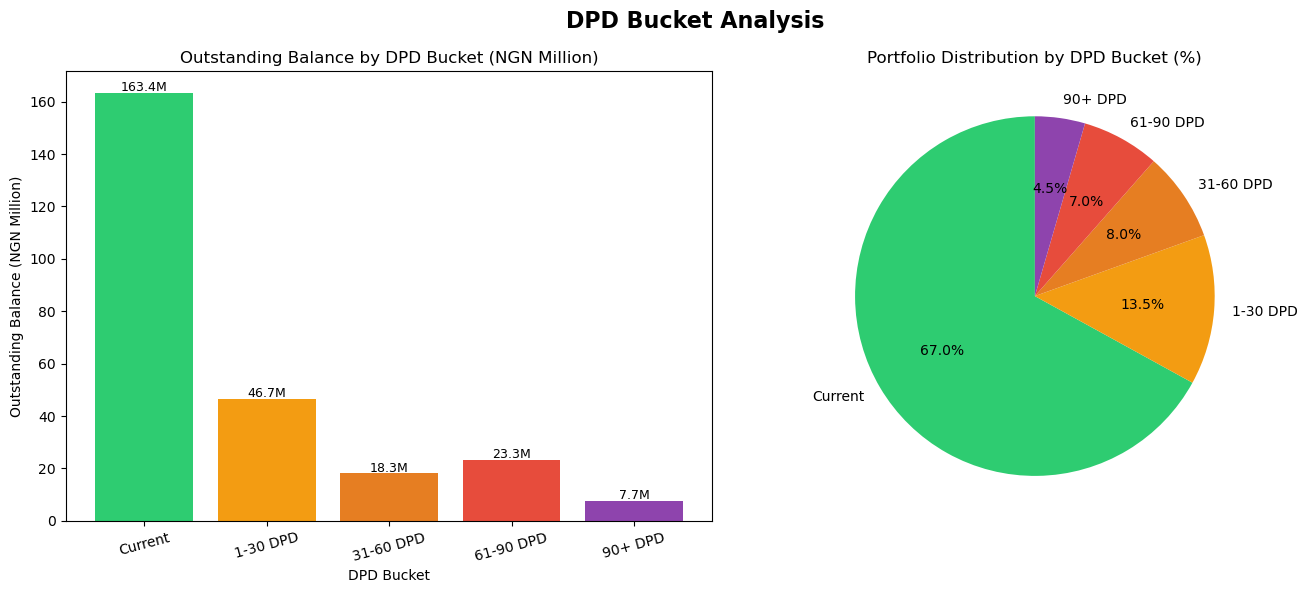

✅ Chart saved to dashboard folder


In [8]:
# ── SECTION 2: DPD BUCKET ANALYSIS ─────────────────────
dpd_analysis = pd.read_sql("""
    SELECT 
        dpd_bucket,
        classification,
        COUNT(*) AS number_of_loans,
        SUM(outstanding_balance) AS total_outstanding,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS percentage_of_portfolio
    FROM dpd_classifications
    GROUP BY dpd_bucket, classification
    ORDER BY 
        CASE dpd_bucket
            WHEN 'Current' THEN 1
            WHEN '1-30 DPD' THEN 2
            WHEN '31-60 DPD' THEN 3
            WHEN '61-90 DPD' THEN 4
            WHEN '90+ DPD' THEN 5
        END
""", engine)

print("=" * 70)
print("                    DPD BUCKET ANALYSIS")
print("=" * 70)
print(dpd_analysis.to_string(index=False))
print("=" * 70)

# Visualisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('DPD Bucket Analysis', fontsize=16, fontweight='bold')

colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c', '#8e44ad']

# Bar chart — outstanding balance by DPD bucket
ax1.bar(dpd_analysis['dpd_bucket'],
        dpd_analysis['total_outstanding'] / 1_000_000,
        color=colors)
ax1.set_title('Outstanding Balance by DPD Bucket (NGN Million)')
ax1.set_xlabel('DPD Bucket')
ax1.set_ylabel('Outstanding Balance (NGN Million)')
ax1.tick_params(axis='x', rotation=15)
for i, v in enumerate(dpd_analysis['total_outstanding'] / 1_000_000):
    ax1.text(i, v + 0.5, f'{v:.1f}M', ha='center', fontsize=9)

# Pie chart — portfolio percentage by classification
ax2.pie(dpd_analysis['percentage_of_portfolio'],
        labels=dpd_analysis['dpd_bucket'],
        autopct='%1.1f%%',
        colors=colors,
        startangle=90)
ax2.set_title('Portfolio Distribution by DPD Bucket (%)')

plt.tight_layout()
plt.savefig('../dashboard/dpd_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to dashboard folder")

           PAR RATIO ANALYSIS
  PAR1  (1+ days past due):  37.0%
  PAR30 (30+ days past due): 19.01%
  PAR60 (60+ days past due): 11.96%
  PAR90 (90+ days past due): 2.97%


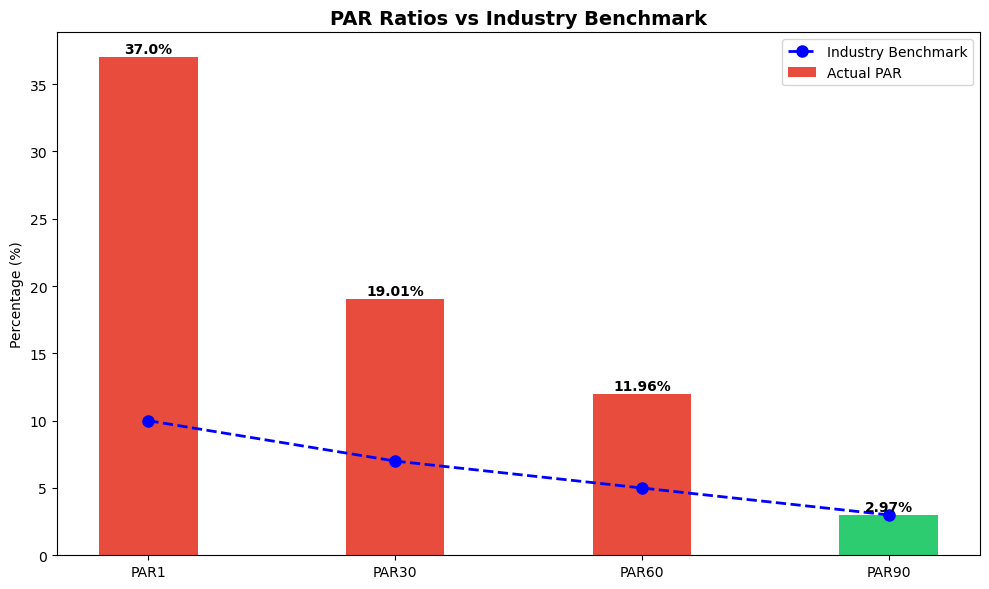

✅ Chart saved to dashboard folder


In [9]:
# ── SECTION 3: PAR RATIO ANALYSIS ──────────────────────
par_analysis = pd.read_sql("""
    SELECT
        ROUND(100.0 * SUM(CASE WHEN days_past_due > 0 THEN outstanding_balance ELSE 0 END) /
        SUM(outstanding_balance), 2) AS PAR1,
        ROUND(100.0 * SUM(CASE WHEN days_past_due > 30 THEN outstanding_balance ELSE 0 END) /
        SUM(outstanding_balance), 2) AS PAR30,
        ROUND(100.0 * SUM(CASE WHEN days_past_due > 60 THEN outstanding_balance ELSE 0 END) /
        SUM(outstanding_balance), 2) AS PAR60,
        ROUND(100.0 * SUM(CASE WHEN days_past_due > 90 THEN outstanding_balance ELSE 0 END) /
        SUM(outstanding_balance), 2) AS PAR90
    FROM dpd_classifications
""", engine)

print("=" * 55)
print("           PAR RATIO ANALYSIS")
print("=" * 55)
print(f"  PAR1  (1+ days past due):  {par_analysis['par1'].values[0]}%")
print(f"  PAR30 (30+ days past due): {par_analysis['par30'].values[0]}%")
print(f"  PAR60 (60+ days past due): {par_analysis['par60'].values[0]}%")
print(f"  PAR90 (90+ days past due): {par_analysis['par90'].values[0]}%")
print("=" * 55)

# Benchmark comparison
benchmarks = [10, 7, 5, 3]
par_values = [
    float(par_analysis['par1'].values[0]),
    float(par_analysis['par30'].values[0]),
    float(par_analysis['par60'].values[0]),
    float(par_analysis['par90'].values[0])
]
par_labels = ['PAR1', 'PAR30', 'PAR60', 'PAR90']

fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(par_labels))
bars = ax.bar(x, par_values, color=['#e74c3c' if v > b else '#2ecc71' 
              for v, b in zip(par_values, benchmarks)], width=0.4, label='Actual PAR')
ax.plot(x, benchmarks, 'bo--', linewidth=2, markersize=8, label='Industry Benchmark')

ax.set_xticks(x)
ax.set_xticklabels(par_labels)
ax.set_title('PAR Ratios vs Industry Benchmark', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)')
ax.legend()

for i, v in enumerate(par_values):
    ax.text(i, v + 0.3, f'{v}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../dashboard/par_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to dashboard folder")

              CONCENTRATION RISK BY EMPLOYER & STATE (TOP 10)
                   employer  state  number_of_loans  total_exposure  exposure_percentage  delinquent_loans  delinquency_rate
                       NNPC Kaduna                6     22231074.77                 4.24                 3              50.0
       Oyo State Government   Kano                5     19927339.63                 3.80                 0               0.0
              Nigerian Army Kaduna                6     17415158.13                 3.32                 0               0.0
                        CBN   Kano                5     17109775.57                 3.26                 3              60.0
Federal Ministry of Finance  Lagos                4     13939385.41                 2.66                 1              25.0
     Lagos State Government  Delta                4     13755112.43                 2.62                 2              50.0
Federal Ministry of Finance  Enugu                5     1356891

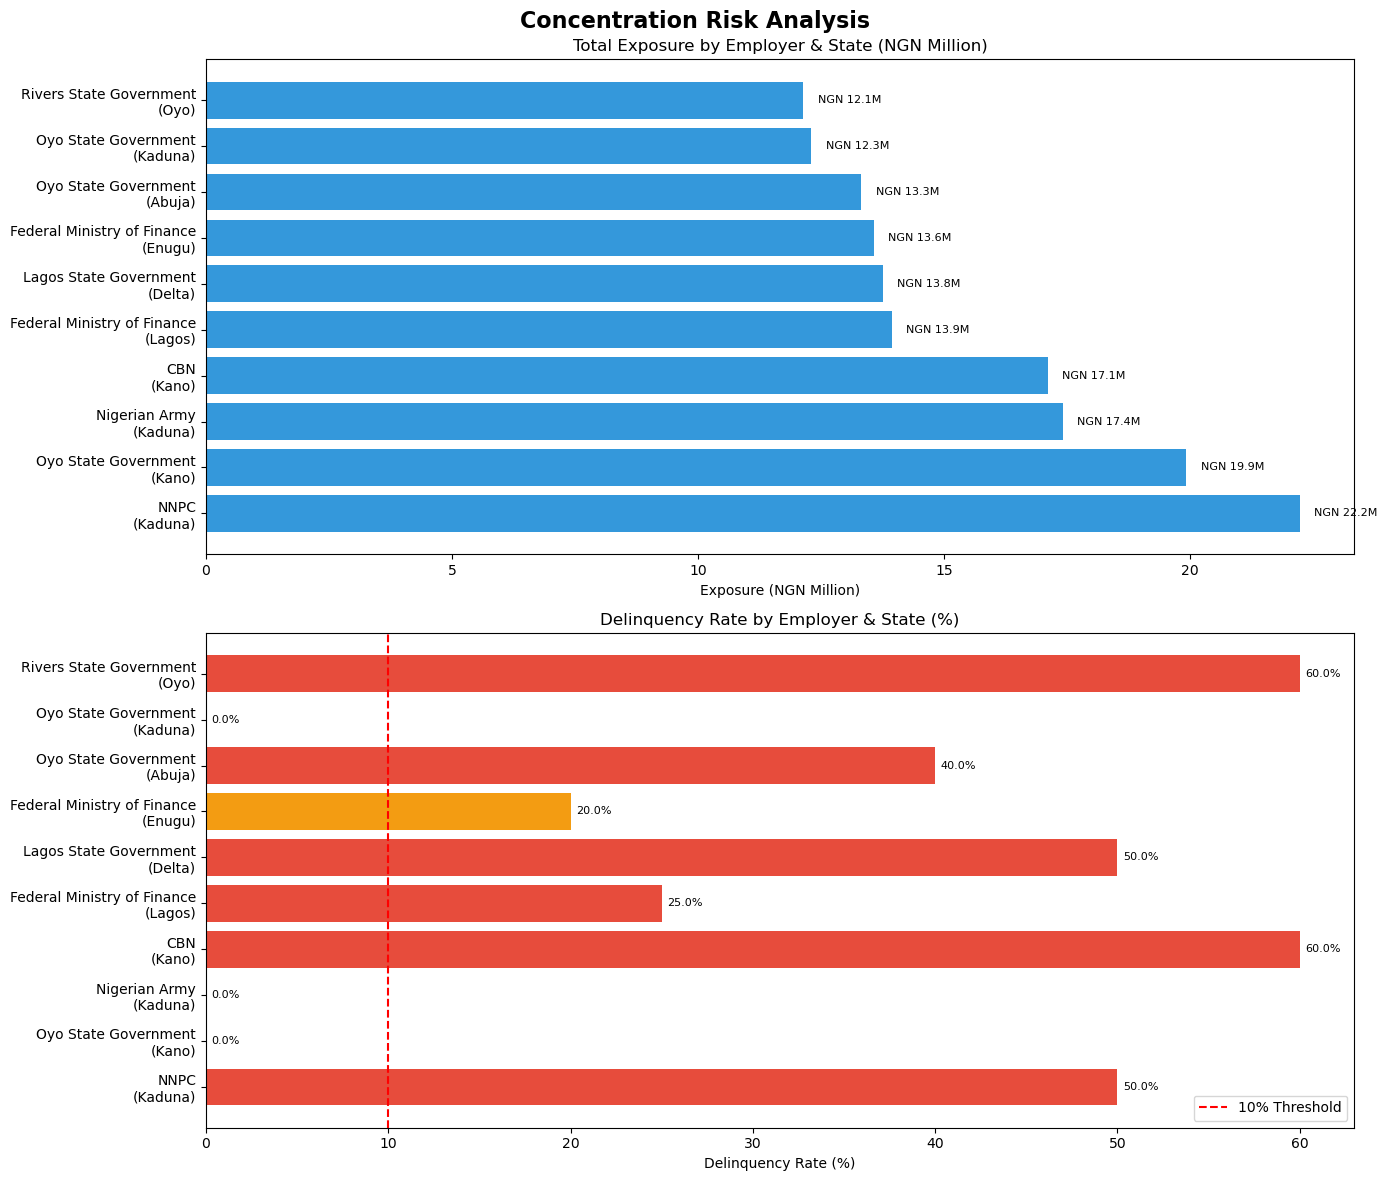

✅ Chart saved to dashboard folder


In [10]:
# ── SECTION 4: CONCENTRATION RISK ──────────────────────
concentration = pd.read_sql("""
    SELECT 
        b.employer,
        b.state,
        COUNT(l.loan_id) AS number_of_loans,
        SUM(l.loan_amount) AS total_exposure,
        ROUND(100.0 * SUM(l.loan_amount) / SUM(SUM(l.loan_amount)) OVER (), 2) AS exposure_percentage,
        SUM(CASE WHEN l.loan_status = 'Delinquent' THEN 1 ELSE 0 END) AS delinquent_loans,
        ROUND(100.0 * SUM(CASE WHEN l.loan_status = 'Delinquent' THEN 1 ELSE 0 END) / 
        COUNT(l.loan_id), 2) AS delinquency_rate
    FROM loans l
    JOIN borrowers b ON l.borrower_id = b.borrower_id
    GROUP BY b.employer, b.state
    ORDER BY total_exposure DESC
    LIMIT 10
""", engine)

print("=" * 80)
print("              CONCENTRATION RISK BY EMPLOYER & STATE (TOP 10)")
print("=" * 80)
print(concentration.to_string(index=False))
print("=" * 80)

# Visualisation
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))
fig.suptitle('Concentration Risk Analysis', fontsize=16, fontweight='bold')

employer_labels = [f"{row['employer']}\n({row['state']})" 
                   for _, row in concentration.iterrows()]

# Top chart — total exposure
bars = ax1.barh(employer_labels, 
                concentration['total_exposure'] / 1_000_000,
                color='#3498db')
ax1.set_title('Total Exposure by Employer & State (NGN Million)')
ax1.set_xlabel('Exposure (NGN Million)')
for i, v in enumerate(concentration['total_exposure'] / 1_000_000):
    ax1.text(v + 0.3, i, f'NGN {v:.1f}M', va='center', fontsize=8)

# Bottom chart — delinquency rate
colors = ['#e74c3c' if r > 20 else '#f39c12' if r > 10 else '#2ecc71' 
          for r in concentration['delinquency_rate']]
ax2.barh(employer_labels,
         concentration['delinquency_rate'],
         color=colors)
ax2.set_title('Delinquency Rate by Employer & State (%)')
ax2.set_xlabel('Delinquency Rate (%)')
ax2.axvline(x=10, color='red', linestyle='--', linewidth=1.5, label='10% Threshold')
ax2.legend()
for i, v in enumerate(concentration['delinquency_rate']):
    ax2.text(v + 0.3, i, f'{v}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('../dashboard/concentration_risk.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to dashboard folder")

                    REPAYMENT PERFORMANCE & COLLECTION RATE BY EMPLOYER
                   employer  number_of_loans  total_amount_due  total_amount_collected  collection_rate  total_shortfall  missed_payments  late_payments  on_time_payments
                       NNPC               19       65988505.79             44635250.20            67.64      21353255.59               33             63               172
       Oyo State Government               26       90264244.44             63516379.93            70.37      26747864.51              108             51               273
      Nigerian Police Force               15       56002385.22             40930629.75            73.09      15071755.47               40             25               157
     Lagos State Government               21       63127266.78             48461733.98            76.77      14665532.80               74             68               185
                        CBN               20       73629978.03           

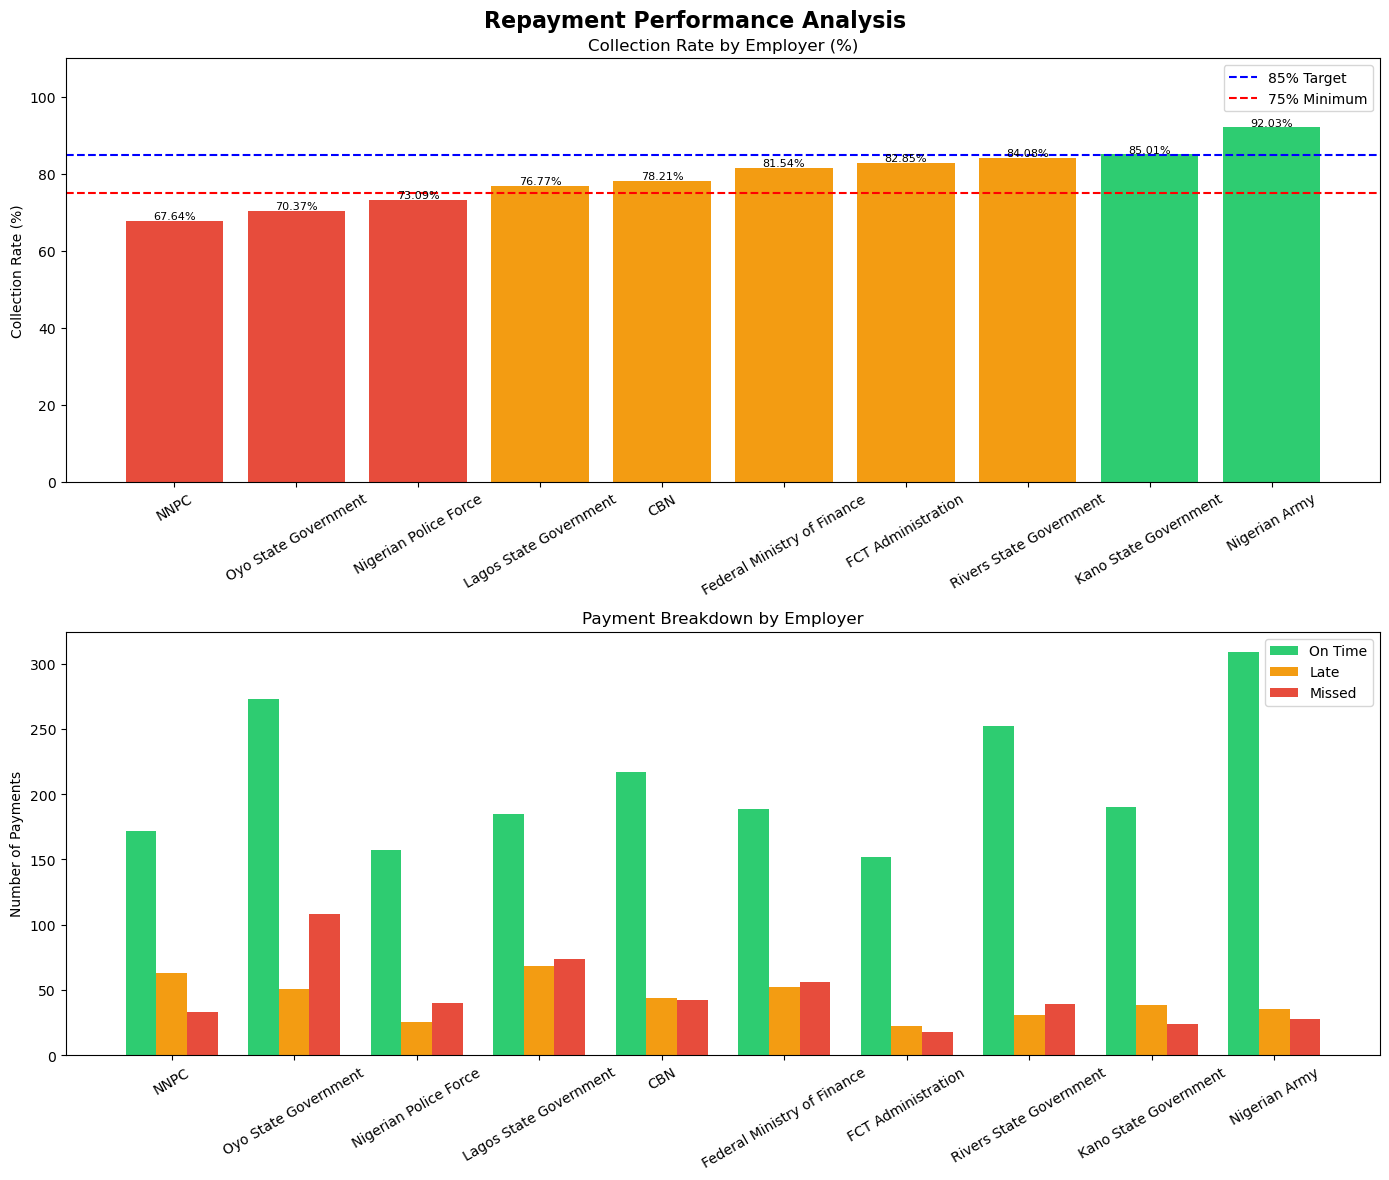

✅ Chart saved to dashboard folder


In [11]:
# ── SECTION 5: REPAYMENT PERFORMANCE ───────────────────
repayment_performance = pd.read_sql("""
    SELECT
        b.employer,
        COUNT(DISTINCT r.loan_id) AS number_of_loans,
        SUM(r.amount_due) AS total_amount_due,
        SUM(r.amount_paid) AS total_amount_collected,
        ROUND(100.0 * SUM(r.amount_paid) / SUM(r.amount_due), 2) AS collection_rate,
        SUM(r.amount_due - r.amount_paid) AS total_shortfall,
        COUNT(CASE WHEN r.payment_status = 'Missed' THEN 1 END) AS missed_payments,
        COUNT(CASE WHEN r.payment_status = 'Late' THEN 1 END) AS late_payments,
        COUNT(CASE WHEN r.payment_status = 'Paid' THEN 1 END) AS on_time_payments
    FROM repayments r
    JOIN loans l ON r.loan_id = l.loan_id
    JOIN borrowers b ON l.borrower_id = b.borrower_id
    GROUP BY b.employer
    ORDER BY collection_rate ASC
""", engine)

print("=" * 90)
print("                    REPAYMENT PERFORMANCE & COLLECTION RATE BY EMPLOYER")
print("=" * 90)
print(repayment_performance.to_string(index=False))
print("=" * 90)

# Visualisation
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))
fig.suptitle('Repayment Performance Analysis', fontsize=16, fontweight='bold')

# Top chart — collection rate
colors = ['#e74c3c' if r < 75 else '#f39c12' if r < 85 else '#2ecc71'
          for r in repayment_performance['collection_rate']]
bars = ax1.bar(repayment_performance['employer'],
               repayment_performance['collection_rate'],
               color=colors)
ax1.axhline(y=85, color='blue', linestyle='--', linewidth=1.5, label='85% Target')
ax1.axhline(y=75, color='red', linestyle='--', linewidth=1.5, label='75% Minimum')
ax1.set_title('Collection Rate by Employer (%)')
ax1.set_ylabel('Collection Rate (%)')
ax1.set_ylim(0, 110)
ax1.tick_params(axis='x', rotation=30)
ax1.legend()
for i, v in enumerate(repayment_performance['collection_rate']):
    ax1.text(i, v + 0.5, f'{v}%', ha='center', fontsize=8)

# Bottom chart — payment breakdown
x = range(len(repayment_performance))
width = 0.25
ax2.bar([i - width for i in x], repayment_performance['on_time_payments'],
        width=width, label='On Time', color='#2ecc71')
ax2.bar(x, repayment_performance['late_payments'],
        width=width, label='Late', color='#f39c12')
ax2.bar([i + width for i in x], repayment_performance['missed_payments'],
        width=width, label='Missed', color='#e74c3c')
ax2.set_xticks(list(x))
ax2.set_xticklabels(repayment_performance['employer'], rotation=30)
ax2.set_title('Payment Breakdown by Employer')
ax2.set_ylabel('Number of Payments')
ax2.legend()

plt.tight_layout()
plt.savefig('../dashboard/repayment_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to dashboard folder")

In [12]:
# ── SECTION 6: EXPORT TO EXCEL REPORT ──────────────────
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

# Export all dataframes to Excel
output_path = '../dashboard/Loan_Portfolio_Analytics_Report.xlsx'

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    portfolio_summary.to_excel(writer, sheet_name='Portfolio Summary', index=False)
    dpd_analysis.to_excel(writer, sheet_name='DPD Analysis', index=False)
    par_analysis.to_excel(writer, sheet_name='PAR Ratios', index=False)
    concentration.to_excel(writer, sheet_name='Concentration Risk', index=False)
    repayment_performance.to_excel(writer, sheet_name='Repayment Performance', index=False)

# Format the workbook
wb = load_workbook(output_path)

header_font = Font(bold=True, color="FFFFFF", size=11)
header_fill = PatternFill(start_color="1A1A1A", end_color="1A1A1A", fill_type="solid")
header_alignment = Alignment(horizontal="center", vertical="center")
thin_border = Border(
    left=Side(style='thin'),
    right=Side(style='thin'),
    top=Side(style='thin'),
    bottom=Side(style='thin')
)

for sheet_name in wb.sheetnames:
    ws = wb[sheet_name]
    # Format headers
    for cell in ws[1]:
        cell.font = header_font
        cell.fill = header_fill
        cell.alignment = header_alignment
        cell.border = thin_border
    # Auto-fit columns
    for col in ws.columns:
        max_length = max(len(str(cell.value or "")) for cell in col)
        ws.column_dimensions[get_column_letter(col[0].column)].width = max_length + 4
    # Format data rows
    for row in ws.iter_rows(min_row=2):
        for cell in row:
            cell.border = thin_border
            cell.alignment = Alignment(horizontal="center")

wb.save(output_path)
print("✅ Excel report saved to dashboard folder")
print(f"   Sheets: {wb.sheetnames}")

✅ Excel report saved to dashboard folder
   Sheets: ['Portfolio Summary', 'DPD Analysis', 'PAR Ratios', 'Concentration Risk', 'Repayment Performance']
